# Hybrid glider trajectory optimizer (corrected)

Minimum weighted probability-of-detection trajectory for a boost-glide vehicle
flown against a co-located radial-velocity + RCS ground sensor. The flight has a
**powered phase** (catapult launch, then thrust as a control) handing off to a
**glide phase** (thrust off) that must reach the goal on the ground.

## What changed relative to the previous version

This revision fixes the three trajectory artifacts (post-handoff zoom climb,
mid-course ground contact, and up/down jitter) at their root causes:

1. **Thrust is now a bang-bang control `T in {0, T_MAX}`** rather than a fixed
   continuous schedule. This is the key change. Under continuous full thrust the
   point-mass vehicle can never pitch to a non-positive flight-path angle within
   the reachable envelope (minimum reachable `gamma` is about +15 deg), so a
   clean descending handoff is *infeasible*. Allowing the optimizer to cut
   thrust (boost, then coast to pitch over) makes a `gamma_sw <= 0` handoff
   feasible and is consistent with minimizing energy.
2. **Hard `gamma_sw <= 0` handoff guard** at the switch point (no soft fallback),
   which removes the forced zoom climb.
3. **Interior ground-clearance floor** that ramps to zero near the goal (a flare),
   removing mid-course ground contact while still allowing a clean landing.
4. **Regularized glide cost**: small time weight plus penalties on `|d gamma|`
   and `|d v|` per step. The speed-smoothness term is what damps the phugoid
   oscillation that produced the jitter.
5. **Smooth trajectory reconstruction** by replaying the stored control sequence
   with sub-stepping (no grid-snapped plotting).
6. **Switch-point selection** by a feasibility filter (descending handoff exists)
   plus minimum combined objective, replacing the old overlap-count heuristic.
   Powered-phase duration bookkeeping is also corrected (it uses `DT_POW`).

Typical end-to-end runtime is about 2 minutes.

In [1]:
import math
import time
import heapq
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Scalar math uses the `math` module (not numpy) inside the DP inner loops:
# this is roughly 1.5x faster than numpy scalar trig and matters a lot here.

## Constants, vehicle, mission geometry, threat parameters

The sensor sits on the ground. For now its range coordinate is the midpoint of
the switch-to-goal segment. Note that this couples the sensor position to the
switch choice; when a defender is added this should become an independent
decision variable (see the closing notes).

In [2]:
# --- physics / vehicle ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))     # lift-coefficient control set
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)                        # bang-bang thrust control

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(45.0)  # 45 deg catapult launch
Z_GOAL, H_GOAL = 2500.0, 0.0
H_SENSOR = 0.0

def sensor_z_of(z_sw):
    """Sensor range coordinate: midpoint of the switch-to-goal segment."""
    return 0.5 * (z_sw + Z_GOAL)

# --- integration time steps ---
DT_GLIDE, DT_POW = 1.0, 0.25

# --- threat model weights ---
RCS_MAX, RCS_MIN = 1.0, 0.1
ALPHA_RCS, ALPHA_SENSOR = 0.1, 0.005
W_RV, W_RCS = 1.0, 1.0

## Dynamics

Standard point-mass longitudinal model. Thrust `T` acts along the flight path
and enters only the speed equation, so the nose is pitched purely
aerodynamically through `CL`. With `T = 0` this is the glide model.

In [3]:
def eom(v, gamma, CL, T):
    """Returns (zdot, hdot, vdot, gammadot)."""
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    """One RK4 step with control (CL, T) held constant over dt."""
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Threat model

Instantaneous weighted probability-of-detection rate, combining a
radial-velocity term (favours flying slowly and tangentially) and an
aspect-dependent RCS term. The acoustic term (powered phase only) is not yet
implemented; see the closing notes.

In [4]:
def podrate(z, h, v, gamma, sz):
    """Weighted detection rate at state (z,h,v,gamma) vs a sensor at range sz."""
    dz = z - sz
    dist = math.hypot(dz, h - H_SENSOR)
    if dist < 1e-6:
        return W_RCS * ALPHA_RCS * RCS_MIN
    vr = abs((v*math.cos(gamma)*dz + v*math.sin(gamma)*(h - H_SENSOR)) / dist)
    ez, eh = (sz - z) / dist, (H_SENSOR - h) / dist
    c = ez * (-math.sin(gamma)) + eh * math.cos(gamma)
    rcs = RCS_MIN + (RCS_MAX - RCS_MIN) * c * c
    return W_RV * ALPHA_SENSOR * vr + W_RCS * ALPHA_RCS * rcs

## State grids, snapping, and the ground-clearance floor

The glide speed grid is capped at `V_MAX_GLIDE` (the glide never exceeds about
45 m/s) which roughly halves the glide state space. The clearance floor is a
fixed height `hc` that ramps linearly to zero over the last `zf` metres before
the goal, allowing a clean flare to touchdown.

In [5]:
V_MAX_GLIDE = 60.0

def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, h_sw + hh + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    """Nearest grid index, or None if out of bounds."""
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    """Minimum allowed altitude at range z: hc, ramping to 0 over the last zf m."""
    d = Z_GOAL - z
    if d >= zf:
        return hc
    if d <= 0:
        return 0.0
    return hc * d / zf

## Powered phase: Dijkstra DP with bang-bang thrust

Forward Dijkstra from the launch state over the search domain, with control
`(CL, T)` and cost `w_time*dt + w_fuel*T*dt`. One solve gives reachability,
cost-to-arrive, and the optimal control into every reachable cell.

`handoff_at` returns the minimum-cost arrival at a given switch cell **subject to
the hard descending-handoff guard `gamma_sw <= 0`**. If no such state exists the
switch point is infeasible.

In [6]:
def powered_dp(gr, w_time, w_fuel):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}
    prev = {}
    cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]
    cnt = 1
    hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9:
            continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax:
                    continue
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None:
                    continue
                nc = c + base
                if nc < V.get(sn, 1e18):
                    V[sn] = nc
                    prev[sn] = (s, CL, T)
                    cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn))
                    cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    """Cheapest powered arrival at (z_sw, h_sw) with gamma_sw <= 0 (hard guard)."""
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']):
        return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9:        # enforce descending handoff
                continue
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv:
                bv, best = V[s], s
    if best is None:
        return None
    z, h, v, g = cont[best]
    return dict(state=best, v=v, gamma=g, cost=bv)

## Glide phase: regularized Dijkstra DP with clearance and early exit

Forward Dijkstra from the handoff state. The step cost is

`podrate*dt  +  w_time*dt  +  w_smooth*|d gamma|  +  w_speed*|d v|`.

The `w_speed` term is essential: it damps the phugoid (the slow speed/altitude
exchange) that otherwise shows up as undulation. The clearance floor is enforced
on every transition. Because costs are non-negative, the first goal-cell state
popped from the queue is optimal, so we stop there (a large speedup).

In [7]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sz, w_time, w_smooth, w_speed, hc, zf, hh):
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None:
        return None
    izg = gr['NZ'] - 1                      # goal range index (grid ends at Z_GOAL)
    V = {s0: 0.0}
    prev = {}
    cont = {s0: (z_sw, h_sw, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]
    cnt = 1
    ceil = h_sw + hh
    goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9:
            continue
        if s[0] == izg and s[1] == 0:       # first popped goal state is optimal
            goal = s
            break
        z, h, v, gm = cont[s]
        pr = podrate(z, h, v, gm, sz)
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if zn < z_sw or vn < V_STALL or hn > ceil:
                continue
            if hn < minclear(zn, hc, zf) - 1e-9:
                continue
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None:
                continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc
                prev[sn] = (s, CL)
                cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn))
                cnt += 1
    return V, prev, cont, s0, goal

## Smooth trajectory reconstruction

Both DPs store the control taken into each cell. We rebuild a trajectory by
replaying that control sequence from the continuous start state, sub-stepping
each control interval, which gives a smooth, dynamically consistent path for
both phases (no grid snapping in the plotted curve).

In [8]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    """Replay stored controls with sub-stepping. T_is_stored=True for the
    powered phase (prev stores (parent, CL, T)); False for glide ((parent, CL))."""
    seq = []
    s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored:
            ps, CL, Tt = e
        else:
            ps, CL = e
            Tt = 0.0
        seq.append((CL, Tt))
        s = ps
    seq.reverse()
    z, h, v, g = cont[s0]
    pts = [(z, h, v, g)]
    sub = dt / substeps
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g))
    return pts

def path_pod(pts, sz, dt_sub):
    """Pure (un-regularized) detection cost integrated along a trajectory."""
    return sum(podrate(z, h, v, g, sz) * dt_sub for (z, h, v, g) in pts[:-1])

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1
        s = prev[s][0]
    return n

## Tunable parameters

All knobs in one place. The most important ones to understand:

- `W_POW_OBJ`: weight of the powered (time + fuel) cost in the switch-selection
  objective. With `W_POW_OBJ = 0` the optimum is **boundary-seeking** (more boost
  buys more protective altitude, and nothing penalizes the boost). A positive
  value creates an interior optimum. See the closing note on flatness.
- `W_SMOOTH`, `W_SPEED`: trajectory shaping. `W_SPEED` damps the phugoid.
- `H_CLEAR`, `Z_FLARE`: ground-clearance floor and flare distance.
- `RANK_GRID` / `FINAL_GRID`: state-grid resolutions used for ranking candidates
  and for the final winner solve.

In [9]:
# glide-cost shaping
W_TIME_GLIDE = 0.005     # small time weight: breaks far-field flat-cost ties
W_SMOOTH     = 2.0       # penalty on |d gamma| per step (rad)
W_SPEED      = 1.5       # penalty on |d v| per step  -> damps the phugoid

# ground clearance
H_CLEAR      = 15.0      # interior clearance floor (m)
Z_FLARE      = 300.0     # clearance ramps 15 m -> 0 over the last 300 m
H_HEADROOM_G = 100.0     # how far above the switch altitude the glide may zoom

# powered cost
W_TIME_POW, W_FUEL_POW = 1.0, 0.1

# switch selection
W_POW_OBJ  = 0.3         # weight of powered cost in the combined objective
V_SW_FLOOR = 16.0        # ignore near-stall handoffs (they cannot glide to goal)
N_RANK     = 9           # max candidates fully evaluated

# state-grid resolutions  (dz, dh in m; dv in m/s; dgam in rad)
RANK_GRID  = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))
FINAL_GRID = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))

## Step 1: solve the powered phase over the switch search domain

In [10]:
t0 = time.time()
grp = pow_grid(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0), zmax=300.0, hmax=200.0)
Vp, prevp, contp, s0p = powered_dp(grp, W_TIME_POW, W_FUEL_POW)
print(f'powered DP: {len(Vp)} states in {time.time()-t0:.1f} s')

powered DP: 109284 states in 11.3 s


## Step 2: enumerate feasible switch candidates

A candidate `(z_sw, h_sw)` is feasible if the powered phase can arrive there with
a descending handoff (`gamma_sw <= 0`) and speed above the stall floor. We take an
even spread across the domain to bound runtime.

In [11]:
raw = []
for z_sw in np.arange(100.0, 300.0 + 1, 50.0):
    for h_sw in np.arange(40.0, 160.0 + 1, 20.0):
        ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
        if ho is None or ho['v'] < V_SW_FLOOR:
            continue
        raw.append((z_sw, h_sw, ho))

if len(raw) > N_RANK:
    idx = np.linspace(0, len(raw) - 1, N_RANK).round().astype(int)
    cands = [raw[i] for i in sorted(set(idx))]
else:
    cands = raw
print(f'{len(raw)} feasible candidates, evaluating {len(cands)}')

28 feasible candidates, evaluating 9


## Step 3: rank candidates by the combined objective

For each candidate we solve the glide phase and score it by

`objective = (pure glide detection cost)  +  W_POW_OBJ * (powered cost)`.

The pure detection cost (not the regularized cost) is used for scoring so the
shaping weights do not bias the switch choice.

In [12]:
t0 = time.time()
results = []
for z_sw, h_sw, ho in cands:
    sz = sensor_z_of(z_sw)
    gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **RANK_GRID)
    out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], sz,
                   W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G)
    if out is None:
        continue
    V, prev, cont, s0, best = out
    if best is None:
        print(f'  z={z_sw:5.0f} h={h_sw:5.0f}  v_sw={ho["v"]:4.1f}  UNREACHABLE')
        continue
    pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=6)
    glide_pod = path_pod(pts, sz, DT_GLIDE / 6)
    obj = glide_pod + W_POW_OBJ * ho['cost']
    results.append((obj, glide_pod, ho['cost'], z_sw, h_sw, ho))
    print(f'  z={z_sw:5.0f} h={h_sw:5.0f}  v_sw={ho["v"]:4.1f}  gam={math.degrees(ho["gamma"]):+5.1f}'
          f'  glidePoD={glide_pod:6.3f}  powcost={ho["cost"]:5.2f}  obj={obj:6.3f}')

results.sort()
print(f'\nranked {len(results)} candidates in {time.time()-t0:.1f} s')
obj, glide_pod, powcost, z_sw, h_sw, ho = results[0]
sz = sensor_z_of(z_sw)
print(f'WINNER: switch=({z_sw:.0f}, {h_sw:.0f})  v_sw={ho["v"]:.1f}  '
      f'gam_sw={math.degrees(ho["gamma"]):+.1f} deg  sensor_z={sz:.0f}')

  z=  100 h=   40  v_sw=16.8  UNREACHABLE
  z=  100 h=  100  v_sw=16.6  gam= -5.3  glidePoD=13.428  powcost=14.25  obj=17.703
  z=  150 h=  100  v_sw=16.6  gam= -7.5  glidePoD=13.101  powcost=13.50  obj=17.151
  z=  200 h=   80  v_sw=24.5  gam= -2.5  glidePoD=12.979  powcost=13.50  obj=17.029
  z=  250 h=   40  v_sw=27.4  UNREACHABLE
  z=  250 h=  100  v_sw=16.0  gam= -6.1  glidePoD=12.618  powcost=17.38  obj=17.830
  z=  250 h=  160  v_sw=22.3  gam= -3.1  glidePoD=12.130  powcost=18.38  obj=17.643
  z=  300 h=  100  v_sw=22.4  gam= -8.9  glidePoD=12.238  powcost=17.50  obj=17.488
  z=  300 h=  160  v_sw=20.8  gam= -2.9  glidePoD=11.836  powcost=19.62  obj=17.723

ranked 7 candidates in 53.2 s
WINNER: switch=(200, 80)  v_sw=24.5  gam_sw=-2.5 deg  sensor_z=1350


## Step 4: final solve at the winner and smooth reconstruction

In [13]:
t0 = time.time()
gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **FINAL_GRID)
Vg, prevg, contg, s0g, bestg = glide_dp(
    gr, z_sw, h_sw, ho['v'], ho['gamma'], sz,
    W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G)

glide_pts = reconstruct(prevg, contg, bestg, s0g, DT_GLIDE, False, substeps=10)
pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=6)

t_pow   = count_steps(prevp, s0p, ho['state']) * DT_POW
t_glide = count_steps(prevg, s0g, bestg)       * DT_GLIDE

gz = [p[0] for p in glide_pts]; gh = [p[1] for p in glide_pts]
gv = [p[2] for p in glide_pts]; gg = [math.degrees(p[3]) for p in glide_pts]
viol = sum(1 for z, h in zip(gz, gh) if h < minclear(z, H_CLEAR, Z_FLARE) - 1.0)
max_dv = max(abs(gv[i+1] - gv[i]) for i in range(len(gv) - 1))
total_pod = path_pod(pow_pts, sz, DT_POW/6) + path_pod(glide_pts, sz, DT_GLIDE/10)

print(f'final glide solve: {time.time()-t0:.1f} s')
print(f'powered duration = {t_pow:.2f} s   ({int(t_pow/DT_POW)} steps x {DT_POW} s)')
print(f'glide duration   = {t_glide:.1f} s')
print(f'total flight time= {t_pow + t_glide:.1f} s')
print(f'min glide altitude = {min(gh):.1f} m   clearance violations = {viol}')
print(f'max |dv| between samples = {max_dv:.3f} m/s   (phugoid check)')
print(f'total detection cost (powered + glide) = {total_pod:.3f}')

final glide solve: 5.2 s
powered duration = 7.25 s   (29 steps x 0.25 s)
glide duration   = 123.0 s
total flight time= 130.2 s
min glide altitude = 0.6 m   clearance violations = 0
max |dv| between samples = 0.161 m/s   (phugoid check)
total detection cost (powered + glide) = 14.122


## Step 5: figure

Top: altitude vs range, with the sensor, switch point, clearance floor, and goal.
Bottom: speed (solid) and flight-path angle (dashed) vs range.

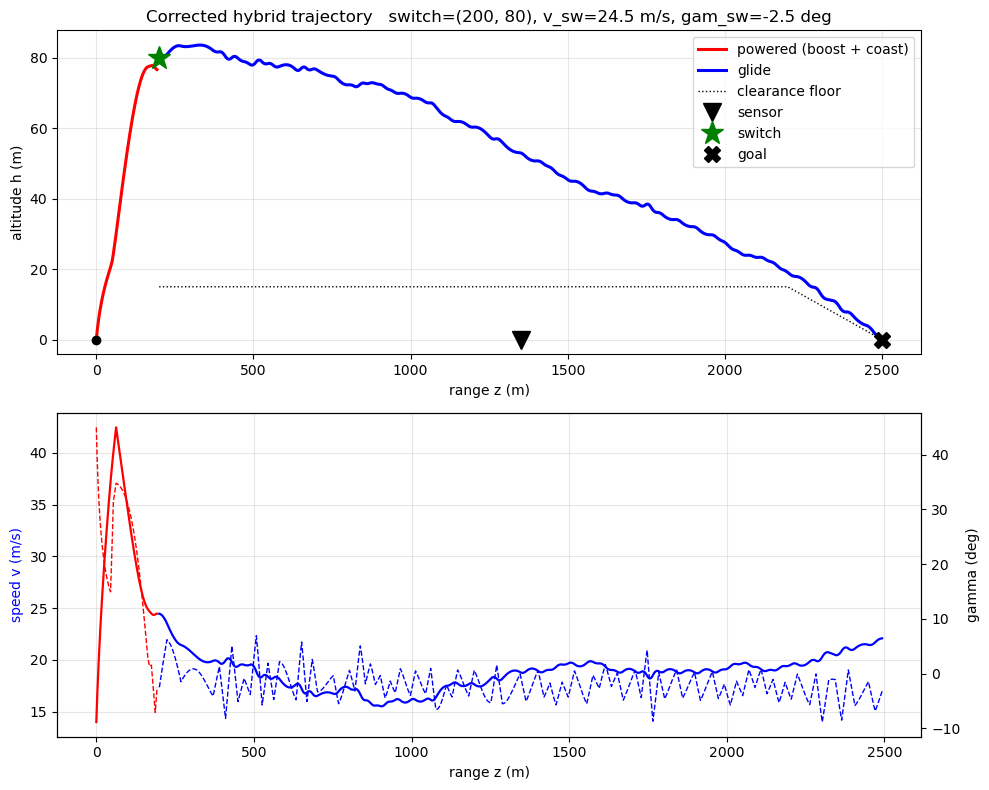

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

pz = [p[0] for p in pow_pts]; ph = [p[1] for p in pow_pts]
ax[0].plot(pz, ph, 'r-', lw=2.2, label='powered (boost + coast)')
ax[0].plot(gz, gh, 'b-', lw=2.2, label='glide')
zf = np.linspace(z_sw, Z_GOAL, 200)
ax[0].plot(zf, [minclear(z, H_CLEAR, Z_FLARE) for z in zf], 'k:', lw=1, label='clearance floor')
ax[0].plot(sz, 0, 'kv', ms=13, label='sensor')
ax[0].plot(z_sw, h_sw, 'g*', ms=17, label='switch')
ax[0].plot(0, 0, 'ko', ms=6)
ax[0].plot(Z_GOAL, 0, 'kX', ms=11, label='goal')
ax[0].set_xlabel('range z (m)'); ax[0].set_ylabel('altitude h (m)')
ax[0].legend(loc='upper right'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'Corrected hybrid trajectory   switch=({z_sw:.0f}, {h_sw:.0f}), '
                f'v_sw={ho["v"]:.1f} m/s, gam_sw={math.degrees(ho["gamma"]):+.1f} deg')

ax[1].plot(pz, [p[2] for p in pow_pts], 'r-', lw=1.6)
ax[1].plot(gz, gv, 'b-', lw=1.6)
ax[1].set_ylabel('speed v (m/s)', color='b'); ax[1].set_xlabel('range z (m)')
ax[1].grid(alpha=0.3)
ax2 = ax[1].twinx()
ax2.plot(pz, [math.degrees(p[3]) for p in pow_pts], 'r--', lw=1)
ax2.plot(gz, gg, 'b--', lw=1)
ax2.set_ylabel('gamma (deg)')

plt.tight_layout()
plt.show()

## Notes, caveats, and next steps

**Why the post-handoff climb is not a bug.** With a clean descending handoff the
glide may still rise slightly before the sensor: altitude lowers the
radial-velocity detection term, so a brief protective zoom can be optimal. The
fixes ensure the handoff is descending and the path is smooth; they do not (and
should not) forbid the glider from trading speed for altitude.

**The switch point is weakly determined right now.** Across the feasible region
the combined objective varies by only a few percent. The pure glide detection
cost falls roughly linearly with extra boost energy, with slope near 0.3 per unit
powered cost, so near `W_POW_OBJ` approximately 0.3 the objective is nearly flat
and the argmin is sensitive to the candidate set and grid. This is a property of
the current cost model, not a solver error. The planned **acoustic detection
term on the powered phase** will add a strong, range-dependent penalty on the
boost and should sharpen the switch selection considerably. Until then, treat the
returned switch as representative and use `W_POW_OBJ` to express how costly the
boost is.

**Sensor position is currently tied to the switch.** `sensor_z_of` places the
sensor at the midpoint of switch-to-goal, so changing the switch moves the
sensor. For an attacker best-response against a fixed defender, hold the sensor
position fixed (independent of the switch) before reading off an optimal switch.
This becomes a genuine decision variable in the Stackelberg setting.

**Open modeling TODOs (carried over).** Add the acoustic term
`P = 1 - exp(-lambda v^n / r^2)` (powered phase only, n about 4 to 6); confirm the
Doppler and RCS forms and the Poisson fusion integral cost; and move to the
non-zero-sum SSG objective (attacker minimizes `a1*P_D + a2*T`, defender maximizes
`b1*P_D + b2*Coverage`).

**Tuning guide.** Increase `W_SPEED` if any phugoid undulation remains; raise
`H_CLEAR` / `Z_FLARE` for a more conservative floor and a longer flare; raise
`W_POW_OBJ` to push the switch earlier (cheaper boost) or lower it to push the
switch outward (more energy). For higher-fidelity trajectories, refine
`FINAL_GRID` (for example `dh=2.0`, `dgam=math.radians(1.0)`); runtime scales
with the state count.